# 🅿️ Analyse Prospection — Application de Partage de Places

**Objectif :** Identifier les zones géographiques prioritaires pour la prospection commerciale d'une app de partage de places de parking entre voisins.

**Sources de données :**
- `Co-proprie_te_.csv` — copropriétés françaises (mandats, lots, stationnement)
- `Parking.csv` — parkings publics (capacités, localisations)
- `recensement-logements.csv` — logements par IRIS (typologies, ménages motorisés)
- `Taux_de_motorisation.csv` — taux de motorisation par IRIS et commune

**KPIs produits :**
1. Score potentiel de partage par ville
2. Classement des zones géographiques (Top N paramétrable)
3. Analyse des mandats de copropriété (ancienneté + alertes commerciales)
4. Ratio places de stationnement / logements par ville

---
## ⚙️ 0. Configuration

In [404]:
import pandas as pd
import sqlite3
import warnings
from datetime import date

warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────────────────────
#  PARAMÈTRES — modifiez ici selon vos besoins
# ─────────────────────────────────────────────────────────────────────────────
TOP_N                  = 20   # Nombre de villes dans le classement prioritaire
SEUIL_FIN_PROCHE_JOURS = 90   # Mandat 'bientôt expiré' si fin < X jours

# ─────────────────────────────────────────────────────────────────────────────
#  CHEMINS ABSOLUS VERS LES FICHIERS CSV
#  ⚠️  Modifiez ces chemins si vous déplacez vos fichiers
# ─────────────────────────────────────────────────────────────────────────────
PATH_COPRO     = '/Users/quentinott/Desktop/B3 YNOV/Projet 48h/copropriete.csv'
PATH_PARKING   = '/Users/quentinott/Desktop/B3 YNOV/Projet 48h/Parking.csv'
PATH_LOGEMENTS = '/Users/quentinott/Desktop/B3 YNOV/Projet 48h/recensement-logements.csv'
PATH_MOTO      = '/Users/quentinott/Desktop/B3 YNOV/Projet 48h/Taux_de_motorisation.csv'

TODAY = date.today().isoformat()
print(f'✅ Configuration OK | Date : {TODAY} | TOP_N = {TOP_N}')
print(f'📂 Copropriété : {PATH_COPRO}')
print(f'📂 Parking     : {PATH_PARKING}')
print(f'📂 Logements   : {PATH_LOGEMENTS}')
print(f'📂 Motorisation: {PATH_MOTO}')


✅ Configuration OK | Date : 2026-03-31 | TOP_N = 20
📂 Copropriété : /Users/quentinott/Desktop/B3 YNOV/Projet 48h/copropriete.csv
📂 Parking     : /Users/quentinott/Desktop/B3 YNOV/Projet 48h/Parking.csv
📂 Logements   : /Users/quentinott/Desktop/B3 YNOV/Projet 48h/recensement-logements.csv
📂 Motorisation: /Users/quentinott/Desktop/B3 YNOV/Projet 48h/Taux_de_motorisation.csv


---
## 📥 1. Chargement des fichiers CSV

In [405]:
# ── Copropriétés ────────────────────────────────────────────────────────────
df_copro_raw = pd.read_csv(
    PATH_COPRO, sep=None, engine='python',
    on_bad_lines='skip'
)
print(f"Copropriétés brut    : {len(df_copro_raw):,} lignes | {df_copro_raw.shape[1]} colonnes")

# ── Parkings publics ────────────────────────────────────────────────────────
df_parking_raw = pd.read_csv(
    PATH_PARKING, sep=None, engine='python',
    on_bad_lines='skip'
)
print(f"Parkings publics brut: {len(df_parking_raw):,} lignes | {df_parking_raw.shape[1]} colonnes")

# ── Recensement logements ───────────────────────────────────────────────────
df_log_raw = pd.read_csv(
    PATH_LOGEMENTS, sep=None, engine='python',
    on_bad_lines='skip'
)
df_log_raw.columns = df_log_raw.columns.str.lstrip('\ufeff')
print(f"Logements brut       : {len(df_log_raw):,} lignes | {df_log_raw.shape[1]} colonnes")

# ── Taux de motorisation ────────────────────────────────────────────────────
df_moto_raw = pd.read_csv(
    PATH_MOTO, sep=None, engine='python',
    on_bad_lines='skip'
)
df_moto_raw.columns = df_moto_raw.columns.str.lstrip('\ufeff')
print(f"Motorisation brut    : {len(df_moto_raw):,} lignes | {df_moto_raw.shape[1]} colonnes")


Copropriétés brut    : 5,000 lignes | 31 colonnes
Parkings publics brut: 826 lignes | 31 colonnes
Logements brut       : 10,000 lignes | 97 colonnes
Motorisation brut    : 10,000 lignes | 7 colonnes


---
## 🧹 2. Nettoyage & Préparation

In [406]:
# ══════════════════════════════════════════════════════════════
#  2.1 — COPROPRIÉTÉS
# ══════════════════════════════════════════════════════════════
df_copro = df_copro_raw.copy()

print("Colonnes originales:")
print(list(df_copro.columns))

# Renommage des colonnes clés
df_copro = df_copro.rename(columns={
    'numero_d_immatriculation'                                   : 'id_copro',
    'date_d_immatriculation'                                     : 'date_immat',
    'date_de_fin_du_dernier_mandat'                              : 'date_fin_mandat',
    'mandat_en_cours_dans_la_copropriete'                        : 'statut_mandat',
    'type_de_syndic_benevole_professionnel_non_connu'             : 'type_syndic',
    'raison_sociale_du_representant_legal'                       : 'nom_syndic',
    'nom_d_usage_de_la_copropriete'                              : 'nom_copro',
    'commune_adresse_de_reference'                               : 'ville',
    'code_postal_adresse_de_reference'                           : 'code_postal',
    'nombre_total_de_lots'                                       : 'nb_lots_total',
    'nombre_total_de_lots_a_usage_d_habitation_de_bureaux_ou_de_comm' : 'nb_lots_hab',
    'nombre_de_lots_de_stationnement'                            : 'nb_lots_stat',
    'commune'                                                  : 'code_commune',
    'nom_officiel_commune'                                       : 'nom_commune',
    'code_officiel_departement'                                  : 'code_dept',
    'nom_officiel_departement'                                   : 'nom_dept',
    'code_officiel_region'                                       : 'code_region',
    'nom_officiel_region'                                        : 'nom_region',
    'periode_de_construction'                                    : 'periode_construction',
    'long'                                                       : 'longitude',
    'lat'                                                        : 'latitude',
})

print("\nColonnes après renommage:")
print(list(df_copro.columns))

# Remplacer les valeurs 'non connu' par NaN
df_copro.replace('non connu', pd.NA, inplace=True)

# Parse des dates
df_copro['date_immat']      = pd.to_datetime(df_copro['date_immat'],      errors='coerce')
df_copro['date_fin_mandat'] = pd.to_datetime(df_copro['date_fin_mandat'], errors='coerce')

# Normaliser code_commune en string 5 chiffres (après renommage)
if 'code_commune' in df_copro.columns:
    df_copro['code_commune'] = df_copro['code_commune'].astype(str).str.zfill(5)
else:
    print("\n⚠️  'code_commune' non trouvé - colonnes disponibles:")
    print([col for col in df_copro.columns if 'code' in col.lower() or 'commune' in col.lower()])

# Conversion colonnes numériques - vérifier d'abord si les colonnes existent
for col in ['nb_lots_hab', 'nb_lots_stat']:
    if col in df_copro.columns:
        df_copro[col] = pd.to_numeric(df_copro[col], errors='coerce').fillna(0)
    else:
        print(f"\n⚠️  Colonne '{col}' non trouvée")

# Garder seulement les colonnes utiles
cols_copro = [
    'id_copro','date_immat','date_fin_mandat','statut_mandat','type_syndic','nom_syndic',
    'nom_copro','ville','code_postal','nb_lots_total','nb_lots_hab','nb_lots_stat',
    'code_commune','nom_commune','code_dept','nom_dept','code_region','nom_region',
    'periode_construction','longitude','latitude'
]
df_copro = df_copro[[c for c in cols_copro if c in df_copro.columns]]

# Supprimer lignes sans code commune valide
if 'code_commune' in df_copro.columns:
    avant = len(df_copro)
    df_copro = df_copro[df_copro['code_commune'].notna() & (df_copro['code_commune'] != 'nan')]
    print(f"\nCopropriétés : {avant:,} → {len(df_copro):,} lignes après nettoyage")
    print(f"  ↳ avec stationnement : {(df_copro['nb_lots_stat'] > 0).sum():,}")
    print(f"  ↳ sans stationnement : {(df_copro['nb_lots_stat'] == 0).sum():,}")
else:
    print("\n⚠️  Impossible de filtrer par code_commune - colonne non trouvée")

Colonnes originales:
['epci', 'commune', 'numero_d_immatriculation', 'date_d_immatriculation', 'date_de_la_derniere_maj', 'type_de_syndic_benevole_professionnel_non_connu', 'identification_du_representant_legal_raison_sociale_et_le_numer', 'raison_sociale_du_representant_legal', 'siret_du_representant_legal', 'code_ape', 'commune_du_representant_legal', 'mandat_en_cours_dans_la_copropriete', 'date_de_fin_du_dernier_mandat', 'nom_d_usage_de_la_copropriete', 'adresse_de_reference', 'numero_et_voie_adresse_de_reference', 'code_postal_adresse_de_reference', 'commune_adresse_de_reference', 'adresse_complementaire_1', 'adresse_complementaire_2', 'adresse_complementaire_3', 'nombre_d_adresses_complementaires', 'long', 'lat', 'date_du_reglement_de_copropriete', 'residence_service', 'syndicat_cooperatif', 'nombre_total_de_lots', 'nombre_total_de_lots_a_usage_d_habitation_de_bureaux_ou_de_comm', 'nombre_de_lots_a_usage_d_habitation', 'nombre_de_lots_de_stationnement']

Colonnes après renommage:


In [407]:
# ════════════════════════════════════════════════════════════════
#  2.2 — PARKINGS PUBLICS
# ════════════════════════════════════════════════════════════════
df_park = df_parking_raw.copy()

df_park = df_park.rename(columns={
    'id'        : 'id_parking',
    'nom'       : 'nom_parking',
    'insee'     : 'code_commune',
    'nb_places' : 'nb_places',
    'nb_pmr'    : 'nb_places_pmr',
    'Xlong'     : 'longitude',
    'Ylat'      : 'latitude',
    'type_usagers': 'type_usagers',
    'gratuit'   : 'gratuit',
})

# Normaliser code_commune
df_park['code_commune'] = df_park['code_commune'].astype(str).str.zfill(5)

# Garder colonnes utiles
cols_park = ['id_parking','nom_parking','code_commune','nb_places','nb_places_pmr',
             'type_usagers','gratuit','longitude','latitude']
df_park = df_park[cols_park]

# Supprimer parkings sans code commune ni places
df_park = df_park[df_park['code_commune'].notna() & df_park['nb_places'].notna()]
df_park['nb_places'] = pd.to_numeric(df_park['nb_places'], errors='coerce').fillna(0).astype(int)

print(f"Parkings publics : {len(df_park):,} lignes | {df_park['nb_places'].sum():,} places totales")

Parkings publics : 826 lignes | 270,559 places totales


In [408]:
# ════════════════════════════════════════════════════════════════
#  2.3 — RECENSEMENT LOGEMENTS
# ════════════════════════════════════════════════════════════════
df_log = df_log_raw.copy()

# Renommage des colonnes clés
df_log = df_log.rename(columns={
    'Commune ou ARM'                                              : 'code_commune',
    'Logements en 2021 (princ)'                                   : 'nb_logements',
    'Résidences principales en 2021 (princ)'                      : 'nb_res_principales',
    'Rés secondaires et logts occasionnels en 2021 (princ)'       : 'nb_res_secondaires',
    'Logements vacants en 2021 (princ)'                           : 'nb_logements_vacants',
    'Maisons en 2021 (princ)'                                     : 'nb_maisons',
    'Appartements en 2021 (princ)'                                : 'nb_appartements',
    'Rés princ type appartement en 2021 (princ)'                  : 'nb_res_princ_appart',
    'Ménages au moins un parking en 2021 (princ)'                 : 'nb_menages_avec_parking',
    'Ménages au moins une voiture en 2021 (princ)'                : 'nb_menages_avec_voiture',
    'Ménages une voiture en 2021 (princ)'                         : 'nb_menages_1voiture',
    'Ménages deux voitures ou plus en 2021 (princ)'               : 'nb_menages_2voitures',
    'Ménages en 2021 (princ)'                                     : 'nb_menages',
    'Rés princ occupées Propriétaires en 2021 (princ)'            : 'nb_proprietaires',
    'Rés princ occupées Locataires en 2021 (princ)'               : 'nb_locataires',
})

# Normaliser code commune
df_log['code_commune'] = df_log['code_commune'].astype(str).str.zfill(5)

# Colonnes numériques à conserver
num_cols_log = [
    'nb_logements','nb_res_principales','nb_res_secondaires','nb_logements_vacants',
    'nb_maisons','nb_appartements','nb_res_princ_appart',
    'nb_menages_avec_parking','nb_menages_avec_voiture',
    'nb_menages_1voiture','nb_menages_2voitures','nb_menages',
    'nb_proprietaires','nb_locataires'
]

# Remplacement des virgules décimales (format fr) et conversion
for col in num_cols_log:
    if col in df_log.columns:
        df_log[col] = df_log[col].astype(str).str.replace(',', '.', regex=False)
        df_log[col] = pd.to_numeric(df_log[col], errors='coerce').fillna(0)

# Agréger par commune (données à la maille IRIS, on remonte à la commune)
agg_log = df_log.groupby('code_commune')[num_cols_log].sum().reset_index()

print(f"Logements agrégés par commune : {len(agg_log):,} communes")

Logements agrégés par commune : 7,259 communes


In [409]:
# ════════════════════════════════════════════════════════════════
#  2.4 — TAUX DE MOTORISATION
# ════════════════════════════════════════════════════════════════
df_moto = df_moto_raw.copy()

df_moto = df_moto.rename(columns={
    'Code Commune'                    : 'code_commune',
    'Nom Commune'                     : 'nom_commune',
    'Taux de motorisation Commune'    : 'taux_moto_commune',
    'Taux de motorisation Département': 'taux_moto_dept',
    'Taux de motorisation IRIS'       : 'taux_moto_iris',
})

df_moto['code_commune'] = df_moto['code_commune'].astype(str).str.zfill(5)

# Conversion virgule → point pour les taux
for col in ['taux_moto_commune','taux_moto_dept','taux_moto_iris']:
    df_moto[col] = df_moto[col].astype(str).str.replace(',', '.', regex=False)
    df_moto[col] = pd.to_numeric(df_moto[col], errors='coerce')

# Agréger par commune (moyenne du taux sur les IRIS)
agg_moto = df_moto.groupby('code_commune').agg(
    nom_commune    = ('nom_commune', 'first'),
    taux_moto      = ('taux_moto_commune', 'mean'),
).reset_index()

print(f"Motorisation agrégée : {len(agg_moto):,} communes")

Motorisation agrégée : 7,860 communes


---
## 🔗 3. Consolidation en un seul dataset + chargement SQLite

In [410]:
# ── Agrégation copros par commune ───────────────────────────────
print("Colonnes disponibles dans df_copro:")
print(list(df_copro.columns))

# Utiliser seulement les colonnes qui existent réellement
agg_copro = df_copro.groupby('code_commune').agg(
    nb_copros         = ('id_copro',    'count'),
    nb_lots_hab_total = ('nb_lots_hab', 'sum'),
    nb_lots_stat_total= ('nb_lots_stat','sum'),
    nb_copros_avec_stat  = ('nb_lots_stat', lambda x: (x > 0).sum()),
    nb_copros_sans_stat  = ('nb_lots_stat', lambda x: (x == 0).sum()),
).reset_index()

print("\nColonnes dans agg_copro:")
print(list(agg_copro.columns))

# ── Agrégation parkings publics par commune ──────────────────────
agg_park = df_park.groupby('code_commune').agg(
    nb_parkings_publics   = ('id_parking', 'count'),
    nb_places_publiques   = ('nb_places',  'sum'),
).reset_index()

# ── Fusion sur code_commune ──────────────────────────────────────
df_communes = agg_copro.merge(agg_log,  on='code_commune', how='left')
df_communes = df_communes.merge(agg_moto, on='code_commune', how='left')
df_communes = df_communes.merge(agg_park, on='code_commune', how='left')

# Remplir les NaN
fill_cols = ['nb_parkings_publics','nb_places_publiques','nb_logements',
             'nb_res_principales','nb_res_secondaires','nb_appartements',
             'nb_maisons','nb_menages','nb_menages_avec_parking',
             'nb_menages_avec_voiture','nb_menages_1voiture','nb_menages_2voitures',
             'nb_proprietaires','nb_locataires','nb_lots_hab_total','nb_lots_stat_total']
for c in fill_cols:
    if c in df_communes.columns:
        df_communes[c] = df_communes[c].fillna(0)

df_communes['taux_moto'] = df_communes['taux_moto'].fillna(df_communes['taux_moto'].median())

print(f"\nDataset consolidé : {len(df_communes):,} communes")
print(f"Noms de ville renseignés : {df_communes['nom_commune'].notna().sum():,} / {len(df_communes):,}")
print(f"Colonnes finales dans df_communes:")
print(list(df_communes.columns))
print(df_communes[['code_commune','nom_commune','nb_copros','nb_lots_stat_total','nb_logements','taux_moto']].head(5).to_string())

Colonnes disponibles dans df_copro:
['id_copro', 'date_immat', 'date_fin_mandat', 'statut_mandat', 'type_syndic', 'nom_syndic', 'nom_copro', 'ville', 'code_postal', 'nb_lots_total', 'nb_lots_hab', 'nb_lots_stat', 'code_commune', 'longitude', 'latitude']

Colonnes dans agg_copro:
['code_commune', 'nb_copros', 'nb_lots_hab_total', 'nb_lots_stat_total', 'nb_copros_avec_stat', 'nb_copros_sans_stat']

Dataset consolidé : 456 communes
Noms de ville renseignés : 82 / 456
Colonnes finales dans df_communes:
['code_commune', 'nb_copros', 'nb_lots_hab_total', 'nb_lots_stat_total', 'nb_copros_avec_stat', 'nb_copros_sans_stat', 'nb_logements', 'nb_res_principales', 'nb_res_secondaires', 'nb_logements_vacants', 'nb_maisons', 'nb_appartements', 'nb_res_princ_appart', 'nb_menages_avec_parking', 'nb_menages_avec_voiture', 'nb_menages_1voiture', 'nb_menages_2voitures', 'nb_menages', 'nb_proprietaires', 'nb_locataires', 'nom_commune', 'taux_moto', 'nb_parkings_publics', 'nb_places_publiques']
  code_comm

In [411]:
# ── Chargement SQLite ────────────────────────────────────────────
conn = sqlite3.connect(':memory:')

# Table principale
df_communes.to_sql('communes', conn, index=False, if_exists='replace')

# Table détail copropriétés (pour KPI mandats)
df_copro['date_immat_str']      = df_copro['date_immat'].dt.strftime('%Y-%m-%d')
df_copro['date_fin_mandat_str'] = df_copro['date_fin_mandat'].dt.strftime('%Y-%m-%d')
df_copro.to_sql('coproprietes', conn, index=False, if_exists='replace')

def sql(query):
    """Exécute une requête SQL et retourne un DataFrame."""
    return pd.read_sql_query(query, conn)

# Vérification
check = sql("SELECT COUNT(*) as nb_communes FROM communes")
print(f"✅ SQLite chargé | communes : {check['nb_communes'][0]:,} | coproprietes : {len(df_copro):,}")

✅ SQLite chargé | communes : 456 | coproprietes : 5,000


In [412]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Style global
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#333355',
    'axes.labelcolor':  '#ccccdd',
    'xtick.color':      '#ccccdd',
    'ytick.color':      '#ccccdd',
    'text.color':       '#ffffff',
    'grid.color':       '#333355',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
})
TEAL   = '#00d4aa'
CORAL  = '#ff6b6b'
AMBER  = '#f5a623'
PURPLE = '#9b59b6'
GREY   = '#555577'
print('✅ Style graphiques chargé')

✅ Style graphiques chargé


---
## 📊 KPI 1 — Score de Potentiel de Partage par Ville

> **Logique métier :** On cherche les villes où les gens ont des voitures ET des places en copropriété → potentiel de mise en partage maximal.
>
> **Composantes du score (sur 100 pts) :**
> - Taux de motorisation élevé → les résidents ont des voitures (×25)
> - Nombre de lots de stationnement en copro → stock de places à partager (×30)
> - Nombre de copros avec stationnement → présence de l'offre (×20)
> - Nombre d'appartements → densité résidentielle = marché (×15)
> - Nombre de ménages avec au moins 1 voiture ET parking → vivier actif (×10)

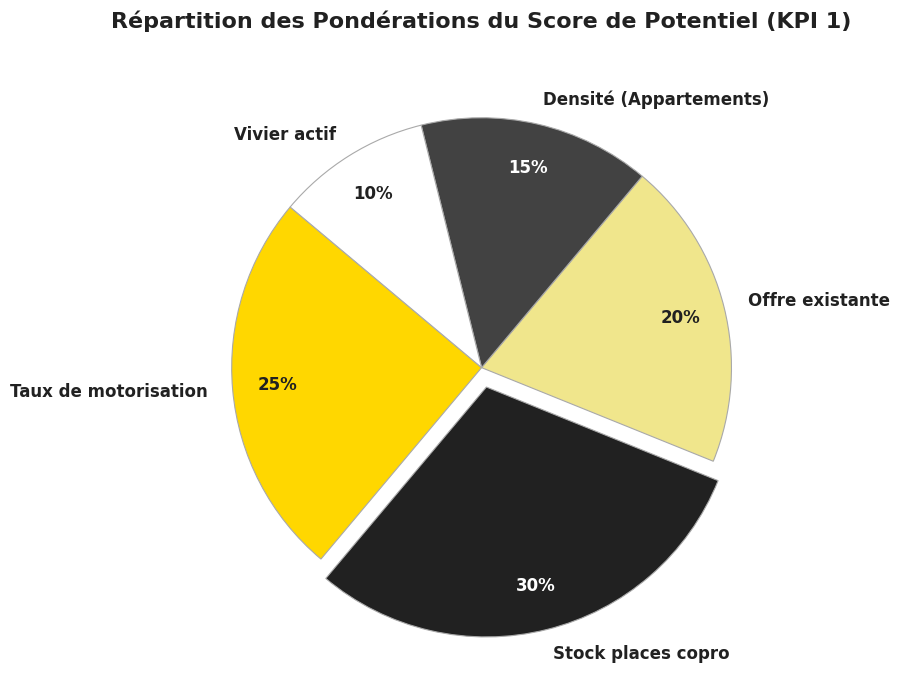

In [433]:
import matplotlib.pyplot as plt

# --- Données du KPI 1 ---
labels = [
    'Taux de motorisation',
    'Stock places copro',
    'Offre existante',
    'Densité (Appartements)',
    'Vivier actif'
]
sizes = [25, 30, 20, 15, 10]

# --- Palette de couleurs optimisée (Jaune/Noir/Blanc) ---
# J'ai choisi des teintes plus "design" : un jaune or, un noir mat, etc.
colors = [
    '#FFD700',  # Jaune Or (Motorisation)
    '#212121',  # Noir Mat (Stock places) - Plus doux que le noir pur
    '#F0E68C',  # Jaune Khaki Clair (Offre existante)
    '#424242',  # Gris Très Foncé (Densité)
    '#FFFFFF'   # Blanc Pur (Vivier actif)
]

# --- Configuration Graphique ---
# Création de la figure avec fond blanc forcé
fig, ax = plt.subplots(figsize=(10, 7), facecolor='white') # Fond blanc de la figure
ax.set_facecolor('white') # Fond blanc des axes

# Génération du camembert
# - J'ai enlevé l'effet d'ombre (shadow=True) pour un look "flat design" plus moderne.
# - J'ai légèrement détaché (explode) le plus gros segment (Stock places) pour le mettre en valeur.
explode = (0, 0.08, 0, 0, 0) 

wedges, texts, autotexts = ax.pie(
    sizes, 
    explode=explode, 
    labels=labels, 
    autopct='%1.0f%%',   # Affichage des pourcentages sans décimale
    startangle=140,      # Angle de départ pour l'esthétique
    colors=colors, 
    shadow=False,        # Look "Flat" moderne
    pctdistance=0.82,    # Position des pourcentages plus proche du bord
    textprops=dict(color="#212121", size=12, weight="bold"), # Texte des étiquettes
    wedgeprops={"edgecolor":"#A9A9A9", 'linewidth': 0.8} # Bordures fines grisées pour séparer le blanc
)

# --- Personnalisation des textes internes (Pourcentages) ---
# Pour qu'ils soient lisibles sur les segments foncés
plt.setp(autotexts, size=12, weight="bold")

# Force la couleur blanche pour le texte dans le segment NOIR (Stock places)
autotexts[1].set_color('white')
# Force la couleur blanche pour le texte dans le segment GRIS FONCÉ (Densité)
autotexts[3].set_color('white')

# Titre du graphique
ax.set_title("Répartition des Pondérations du Score de Potentiel (KPI 1)", 
             size=16, weight="bold", pad=20, color="#212121")

# Affichage propre et minimaliste
plt.tight_layout()
plt.show()

In [413]:
kpi1 = sql(f"""
WITH base AS (
    SELECT
        code_commune,
        COALESCE(nom_commune, code_commune) AS ville,
        code_commune AS departement,
        code_commune AS region,
        CAST(nb_copros            AS REAL)   AS nb_copros,
        CAST(nb_lots_stat_total   AS REAL)   AS nb_lots_stat,
        CAST(nb_copros_avec_stat  AS REAL)   AS nb_copros_avec_stat,
        CAST(nb_appartements      AS REAL)   AS nb_appartements,
        CAST(nb_logements         AS REAL)   AS nb_logements,
        CAST(nb_menages_avec_voiture AS REAL) AS nb_menages_voiture,
        CAST(nb_menages_avec_parking AS REAL) AS nb_menages_parking,
        CAST(taux_moto            AS REAL)   AS taux_moto,
        CAST(nb_places_publiques  AS REAL)   AS nb_places_pub
    FROM communes
    WHERE nb_logements > 50
      AND nb_copros > 0
),
stats AS (
    SELECT
        MAX(nb_lots_stat)        AS max_stat,
        MAX(nb_copros_avec_stat) AS max_copros_stat,
        MAX(nb_appartements)     AS max_appart,
        MAX(taux_moto)           AS max_moto,
        MAX(nb_menages_voiture)  AS max_menages_voit
    FROM base
    WHERE nb_lots_stat > 0
)
SELECT
    b.code_commune,
    b.ville,
    b.departement,
    b.region,
    CAST(b.nb_copros         AS INTEGER) AS nb_copros,
    CAST(b.nb_lots_stat      AS INTEGER) AS lots_stationnement_copro,
    CAST(b.nb_copros_avec_stat AS INTEGER) AS copros_avec_stat,
    CAST(b.nb_appartements   AS INTEGER) AS nb_appartements,
    CAST(b.nb_logements      AS INTEGER) AS nb_logements,
    CAST(b.nb_menages_voiture AS INTEGER) AS menages_avec_voiture,
    ROUND(b.taux_moto * 100, 1)          AS taux_motorisation_pct,
    CAST(b.nb_places_pub     AS INTEGER) AS places_publiques,

    -- Calcul des composantes du score (0–100 chacune, pondérées)
    ROUND(
        -- 25 pts : taux motorisation
        (b.taux_moto / NULLIF(s.max_moto, 0)) * 25
        -- 30 pts : lots stationnement copro
      + (b.nb_lots_stat / NULLIF(s.max_stat, 0)) * 30
        -- 20 pts : copros avec stationnement
      + (b.nb_copros_avec_stat / NULLIF(s.max_copros_stat, 0)) * 20
        -- 15 pts : densité appartements
      + (b.nb_appartements / NULLIF(s.max_appart, 0)) * 15
        -- 10 pts : ménages motorisés
      + (b.nb_menages_voiture / NULLIF(s.max_menages_voit, 0)) * 10
    , 1) AS score_potentiel,

    CASE
        WHEN b.nb_lots_stat > 0 AND b.taux_moto > 0.8  THEN '🔥 Fort potentiel'
        WHEN b.nb_lots_stat > 0 AND b.taux_moto > 0.6  THEN '✅ Bon potentiel'
        WHEN b.nb_lots_stat > 0                         THEN '🟡 Potentiel modéré'
        ELSE                                                 '⬜ Faible potentiel'
    END AS profil

FROM base b, stats s
WHERE b.nb_lots_stat > 0
ORDER BY score_potentiel DESC
""")

print(f"✅ KPI 1 — {len(kpi1):,} villes avec potentiel de partage")
print(f"  ↳ Villes avec nom réel : {(kpi1['ville'] != kpi1['code_commune']).sum()} / {len(kpi1)}")
kpi1.head(20)

✅ KPI 1 — 70 villes avec potentiel de partage
  ↳ Villes avec nom réel : 54 / 70


,code_commune,ville,departement,region,nb_copros,lots_stationnement_copro,copros_avec_stat,nb_appartements,nb_logements,menages_avec_voiture,taux_motorisation_pct,places_publiques,score_potentiel,profil
0,68224,Mulhouse,68224,68224,103,1319,43,50028,58439,32489,67.3,0,77.5,✅ Bon potentiel
1,67482,Strasbourg,67482,67482,48,567,20,149471,162246,86270,62.5,11554,64.6,✅ Bon potentiel
2,57463,Metz,57463,57463,32,899,27,60466,70903,43467,73.0,9726,64.4,✅ Bon potentiel
3,69029,Bron,69029,69029,14,1167,12,16491,19831,14114,76.6,0,56.7,✅ Bon potentiel
4,66136,Perpignan,66136,66136,82,578,24,54107,73808,43671,73.5,0,55.2,✅ Bon potentiel
5,69256,Vaulx-en-Velin,69256,69256,20,1010,16,16418,20353,13531,71.1,11,53.4,✅ Bon potentiel
6,69388,Lyon 8e Arrondissement,69388,69388,27,619,13,46285,49135,28209,65.2,0,46.2,✅ Bon potentiel
7,63113,Clermont-Ferrand,63113,63113,9,349,6,75235,91873,57276,72.7,0,45.1,✅ Bon potentiel
8,69266,Villeurbanne,69266,69266,11,397,8,82362,89281,48874,65.3,468,44.8,✅ Bon potentiel
9,54395,Nancy,54395,54395,31,238,19,63764,71856,37862,63.3,0,42.6,✅ Bon potentiel


### 📈 Graphique KPI 1 — Score potentiel par ville

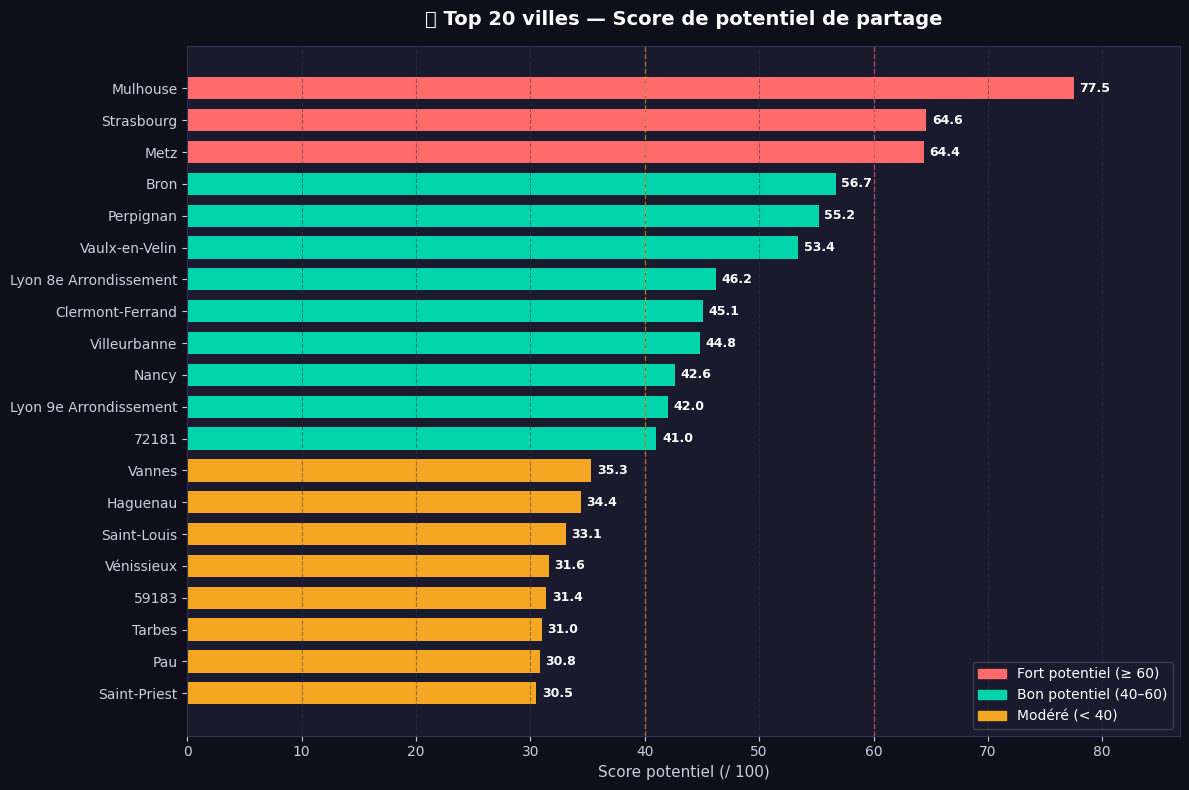

In [429]:
# ── KPI 1 — Top 20 villes par score potentiel ───────────────────────────────
df_g1 = kpi1.head(20).sort_values('score_potentiel')

colors = [CORAL if s >= 60 else TEAL if s >= 40 else AMBER for s in df_g1['score_potentiel']]

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(df_g1['ville'], df_g1['score_potentiel'], color=colors, edgecolor='none', height=0.7)

for bar, val in zip(bars, df_g1['score_potentiel']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9, color='white', fontweight='bold')

ax.set_xlabel('Score potentiel (/ 100)', fontsize=11)
ax.set_title('🅿️ Top 20 villes — Score de potentiel de partage', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, df_g1['score_potentiel'].max() * 1.12)
ax.axvline(x=60, color=CORAL,  linestyle='--', alpha=0.6, linewidth=1)
ax.axvline(x=40, color=AMBER,  linestyle='--', alpha=0.6, linewidth=1)
ax.grid(axis='x')

legend = [
    mpatches.Patch(color=CORAL,  label='Fort potentiel (≥ 60)'),
    mpatches.Patch(color=TEAL,   label='Bon potentiel (40–60)'),
    mpatches.Patch(color=AMBER,  label='Modéré (< 40)'),
]
ax.legend(handles=legend, loc='lower right', framealpha=0.2)
plt.tight_layout()
plt.savefig('graph_kpi1_score_villes.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📊 KPI 2 — Classement des Zones Géographiques (Top N)

> **Lecture :** Les zones Priorité 1 sont celles à cibler en premier pour la prospection et la publicité. Le paramètre `TOP_N` est défini en cellule 0.

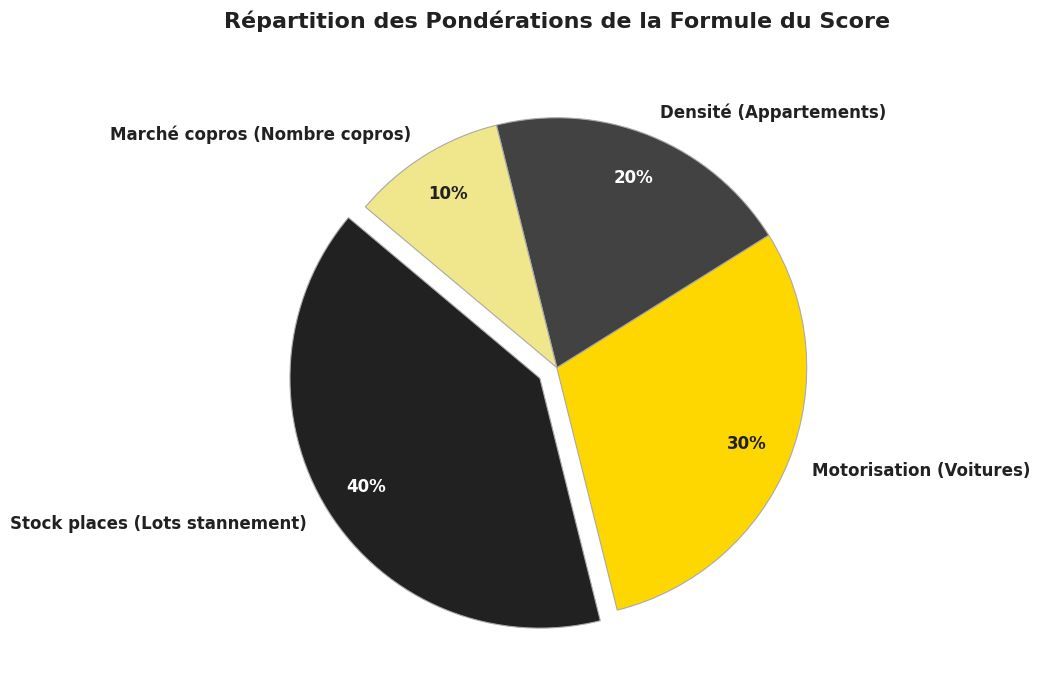

In [434]:
import matplotlib.pyplot as plt
import numpy as np

# --- Données des pondérations (Poids de la formule) ---
labels = [
    'Stock places (Lots stannement)',
    'Motorisation (Voitures)',
    'Densité (Appartements)',
    'Marché copros (Nombre copros)'
]

# Les poids de la formule (0.4, 0.3, 0.2, 0.1) sont exprimés sur 100
sizes = [40, 30, 20, 10]

# --- Palette de couleurs optimisée (Jaune/Noir/Blanc) ---
# J'ai sélectionné des teintes modernes pour un rendu plus beau et lisible
colors = [
    '#212121',  # Noir Mat (Stock places - Plus gros segment)
    '#FFD700',  # Jaune Or (Motorisation)
    '#424242',  # Gris Très Foncé (Densité)
    '#F0E68C'   # Jaune Khaki Clair (Nombre copros)
]

# --- Configuration Graphique ---
# Création de la figure avec un fond blanc pour une intégration propre
fig, ax = plt.subplots(figsize=(10, 7), facecolor='white')

# Génération du camembert (pie chart)
# - Look "Flat Design" moderne (shadow=False)
# - Explosion légère du plus gros segment (Stock places) pour le mettre en valeur.
explode = (0.08, 0, 0, 0) 

wedges, texts, autotexts = ax.pie(
    sizes, 
    explode=explode, 
    labels=labels, 
    autopct='%1.0f%%',   # Affichage des pourcentages sans décimale
    startangle=140,      # Angle de départ pour l'esthétique
    colors=colors, 
    shadow=False,        # Style moderne et minimaliste
    pctdistance=0.82,    # Position des pourcentages
    textprops=dict(color="#212121", size=12, weight="bold"), # Texte des étiquettes
    wedgeprops={"edgecolor":"#A9A9A9", 'linewidth': 0.8} # Bordures fines grisées
)

# --- Personnalisation des textes internes (Pourcentages) ---
# Pour qu'ils soient lisibles sur les segments foncés
plt.setp(autotexts, size=12, weight="bold")

# Force la couleur blanche pour le texte dans le segment NOIR (Stock places)
autotexts[0].set_color('white')
# Force la couleur blanche pour le texte dans le segment GRIS FONCÉ (Densité)
autotexts[2].set_color('white')

# Titre du graphique
ax.set_title("Répartition des Pondérations de la Formule du Score", 
             size=16, weight="bold", pad=20, color="#212121")

# Affichage propre et minimaliste
plt.tight_layout()
plt.show()

In [ ]:
kpi2_villes = sql(f"""
WITH base AS (
    SELECT
        code_commune,
        COALESCE(nom_commune, code_commune) AS ville,
        code_commune AS departement,
        code_commune AS region,
        CAST(nb_copros              AS REAL) AS nb_copros,
        CAST(nb_lots_stat_total     AS REAL) AS nb_lots_stat,
        CAST(nb_copros_avec_stat    AS REAL) AS nb_copros_avec_stat,
        CAST(nb_appartements        AS REAL) AS nb_appartements,
        CAST(nb_logements           AS REAL) AS nb_logements,
        CAST(nb_menages_avec_voiture AS REAL) AS nb_menages_voiture,
        CAST(nb_menages_avec_parking AS REAL) AS nb_menages_parking,
        CAST(taux_moto              AS REAL) AS taux_moto,
        CAST(nb_places_publiques    AS REAL) AS nb_places_pub
    FROM communes
    WHERE nb_logements > 50
      AND nb_copros > 0
),
stats AS (
    SELECT
        MAX(nb_lots_stat)        AS max_stat,
        MAX(nb_copros_avec_stat) AS max_copros_stat,
        MAX(nb_appartements)     AS max_appart,
        MAX(taux_moto)           AS max_moto,
        MAX(nb_menages_voiture)  AS max_menages_voit
    FROM base
    WHERE nb_lots_stat > 0
),
scored AS (
    SELECT
        b.code_commune,
        b.ville,
        b.departement,
        b.region,
        CAST(b.nb_copros AS INTEGER)            AS nb_copros,
        CAST(b.nb_lots_stat AS INTEGER)         AS lots_stationnement,
        CAST(b.nb_appartements AS INTEGER)      AS nb_appartements,
        CAST(b.nb_logements AS INTEGER)         AS nb_logements,
        ROUND(b.taux_moto * 100, 1)             AS taux_motorisation_pct,
        ROUND(
            (b.taux_moto / NULLIF(s.max_moto, 0)) * 25
          + (b.nb_lots_stat / NULLIF(s.max_stat, 0)) * 30
          + (b.nb_copros_avec_stat / NULLIF(s.max_copros_stat, 0)) * 20
          + (b.nb_appartements / NULLIF(s.max_appart, 0)) * 15
          + (b.nb_menages_voiture / NULLIF(s.max_menages_voit, 0)) * 10
        , 1) AS score_potentiel
    FROM base b, stats s
    WHERE b.nb_lots_stat > 0
),
ranked AS (
    SELECT
        ROW_NUMBER() OVER (ORDER BY score_potentiel DESC) AS rang,
        ville,
        departement,
        region,
        nb_copros,
        lots_stationnement,
        nb_appartements,
        nb_logements,
        taux_motorisation_pct,
        score_potentiel
    FROM scored
)
SELECT
    rang,
    ville,
    departement,
    region,
    nb_copros,
    lots_stationnement,
    nb_appartements,
    nb_logements,
    taux_motorisation_pct,
    score_potentiel,
    CASE
        WHEN rang <= 4  THEN '🔴 Priorité 1 — À cibler en urgence'
        WHEN rang <= 10 THEN '🟠 Priorité 2 — Fort intérêt'
        ELSE                 '🟡 Priorité 3 — Potentiel à surveiller'
    END AS niveau_priorite
FROM ranked
LIMIT 20
""")
 
print(f"✅ KPI 2 — Top 20 zones prioritaires")
print(f"  ↳ Villes avec nom réel : {(kpi2_villes['ville'] != kpi2_villes['departement']).sum()} / {len(kpi2_villes)}")
kpi2_villes

✅ KPI 2 — Top 20 zones prioritaires
  ↳ Villes avec nom réel : 18 / 20


,rang,ville,departement,region,nb_copros,lots_stationnement,nb_appartements,nb_logements,taux_motorisation_pct,score_potentiel,niveau_priorite
0,1,Strasbourg,67482,67482,48,567,149471,162246,62.5,49.2,🔴 Priorité 1 — À cibler en urgence
1,2,Mulhouse,68224,68224,103,1319,50028,58439,67.3,42.7,🔴 Priorité 1 — À cibler en urgence
2,3,Metz,57463,57463,32,899,60466,70903,73.0,41.4,🔴 Priorité 1 — À cibler en urgence
3,4,Perpignan,66136,66136,82,578,54107,73808,73.5,38.5,🔴 Priorité 1 — À cibler en urgence
4,5,Clermont-Ferrand,63113,63113,9,349,75235,91873,72.7,37.5,🟠 Priorité 2 — Fort intérêt
5,6,Villeurbanne,69266,69266,11,397,82362,89281,65.3,35.8,🟠 Priorité 2 — Fort intérêt
6,7,72181,72181,72181,12,243,48301,84192,76.2,34.9,🟠 Priorité 2 — Fort intérêt
7,8,Bron,69029,69029,14,1167,16491,19831,76.6,33.5,🟠 Priorité 2 — Fort intérêt
8,9,Nancy,54395,54395,31,238,63764,71856,63.3,33.1,🟠 Priorité 2 — Fort intérêt
9,10,Lyon 8e Arrondissement,69388,69388,27,619,46285,49135,65.2,31.9,🟠 Priorité 2 — Fort intérêt


In [416]:
# Classement par département
kpi2_depts = sql("""
SELECT
    code_commune AS departement,
    code_commune AS region,
    COUNT(*)                             AS nb_communes,
    SUM(CAST(nb_copros AS INTEGER))      AS nb_copros_total,
    SUM(CAST(nb_lots_stat_total AS INTEGER)) AS lots_stat_total,
    SUM(CAST(nb_logements AS INTEGER))   AS nb_logements_total,
    ROUND(AVG(taux_moto) * 100, 1)       AS taux_moto_moyen_pct,
    ROUND(
        (AVG(taux_moto) / (SELECT MAX(taux_moto) FROM communes WHERE taux_moto > 0)) * 25
      + (SUM(CAST(nb_lots_stat_total AS REAL)) / (SELECT MAX(CAST(nb_lots_stat_total AS REAL)) FROM communes) + 1) * 30
      + (SUM(CAST(nb_appartements AS REAL)) / (SELECT MAX(CAST(nb_appartements AS REAL)) FROM communes) + 1) * 25
    , 1) AS score_dept
FROM communes
WHERE nb_copros > 0
GROUP BY code_commune
HAVING nb_copros_total > 5
ORDER BY score_dept DESC
LIMIT 20
""")

print("✅ KPI 2b — Top 20 départements")
print(f"  ↳ Départements avec code : {len(kpi2_depts)}")
kpi2_depts

✅ KPI 2b — Top 20 départements
  ↳ Départements avec code : 20


,departement,region,nb_communes,nb_copros_total,lots_stat_total,nb_logements_total,taux_moto_moyen_pct,score_dept
0,93066,93066,1,396,5099,0,76.2,106.2
1,67482,67482,1,48,567,162246,62.5,100.7
2,59350,59350,1,296,3127,0,76.2,94.6
3,91228,91228,1,33,2615,0,76.2,91.6
4,57463,57463,1,32,899,70903,73.0,90.7
5,93001,93001,1,105,2417,0,76.2,90.4
6,63113,63113,1,9,349,91873,72.7,89.9
7,68224,68224,1,103,1319,58439,67.3,89.8
8,34172,34172,1,28,2291,0,76.2,89.6
9,69266,69266,1,11,397,89281,65.3,89.2


### 📈 Graphique KPI 2 — Zones géographiques

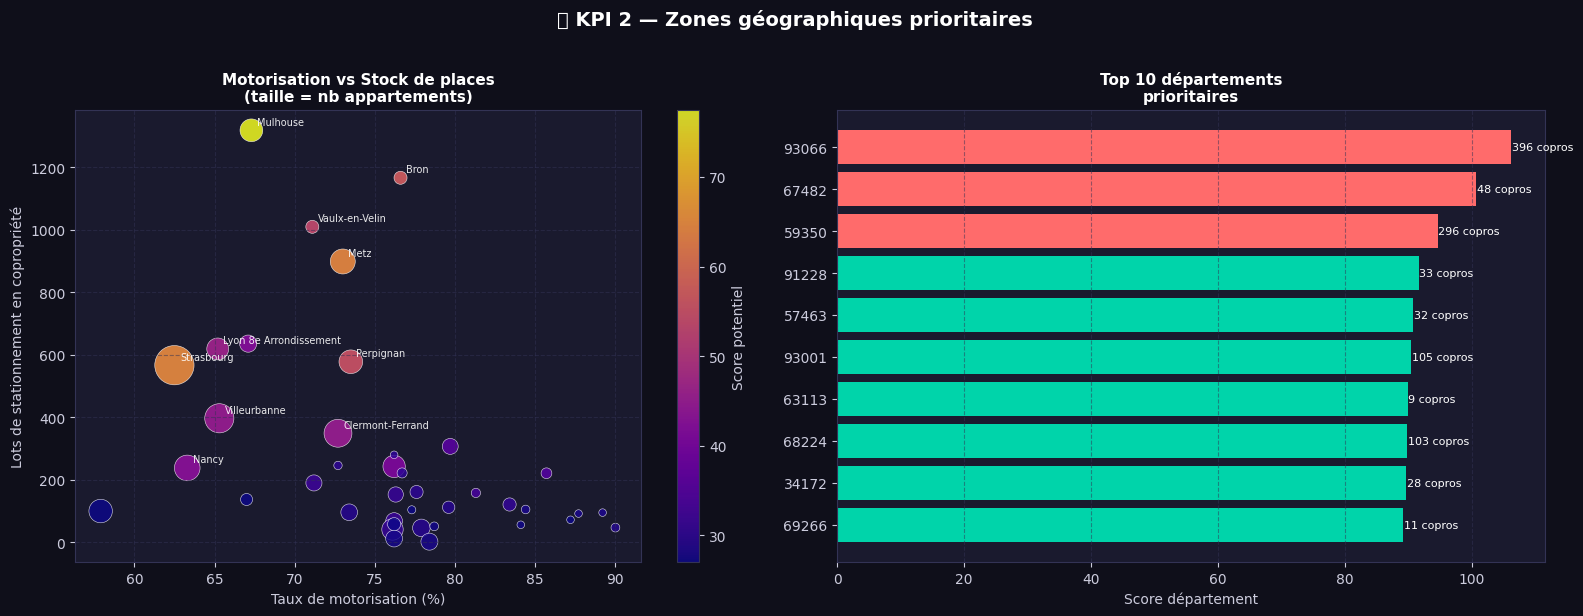

In [417]:
# ── KPI 2 — Scatter : taux motorisation vs lots stationnement ───────────────
df_g2 = kpi1.head(40).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Scatter taux moto vs lots stat, taille = nb appartements ---
ax = axes[0]
sizes = (df_g2['nb_appartements'] / df_g2['nb_appartements'].max() * 800).clip(30)
sc = ax.scatter(
    df_g2['taux_motorisation_pct'], df_g2['lots_stationnement_copro'],
    c=df_g2['score_potentiel'], cmap='plasma',
    s=sizes, alpha=0.85, edgecolors='white', linewidths=0.4
)
plt.colorbar(sc, ax=ax, label='Score potentiel')
# Labels top 10
for _, row in df_g2.head(10).iterrows():
    ax.annotate(row['ville'], (row['taux_motorisation_pct'], row['lots_stationnement_copro']),
                fontsize=7, color='white', alpha=0.9,
                xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('Taux de motorisation (%)')
ax.set_ylabel('Lots de stationnement en copropriété')
ax.set_title('Motorisation vs Stock de places\n(taille = nb appartements)', fontsize=11, fontweight='bold')
ax.grid(True)

# --- Barres top 10 depts ---
ax2 = axes[1]
df_dep = kpi2_depts.head(10).sort_values('score_dept')
bar_colors = [CORAL if s >= df_dep['score_dept'].quantile(0.7) else TEAL for s in df_dep['score_dept']]
ax2.barh(df_dep['departement'], df_dep['score_dept'], color=bar_colors, edgecolor='none')
ax2.set_xlabel('Score département')
ax2.set_title('Top 10 départements\nprioritaires', fontsize=11, fontweight='bold')
ax2.grid(axis='x')
for i, (val, label) in enumerate(zip(df_dep['score_dept'], df_dep['nb_copros_total'])):
    ax2.text(val + 0.1, i, f'{label} copros', va='center', fontsize=8, color='white')

fig.suptitle('🗺️ KPI 2 — Zones géographiques prioritaires', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('graph_kpi2_zones.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📊 KPI 3 — Analyse des Mandats de Copropriété

> **Règles commerciales :**
> - ✅ **Cibler** : mandats récents ou établis, copros avec beaucoup de places de stationnement
> - ⚠️ **Éviter** : mandats expirant dans moins de 90 jours (transition en cours, interlocuteur instable)
> - ❌ **Exclure** : mandats expirés sans successeur (situation incertaine)
>
> **Ancienneté :** Nouveau < 6 mois | Récent 6–24 mois | Établi 2–5 ans | Historique > 5 ans

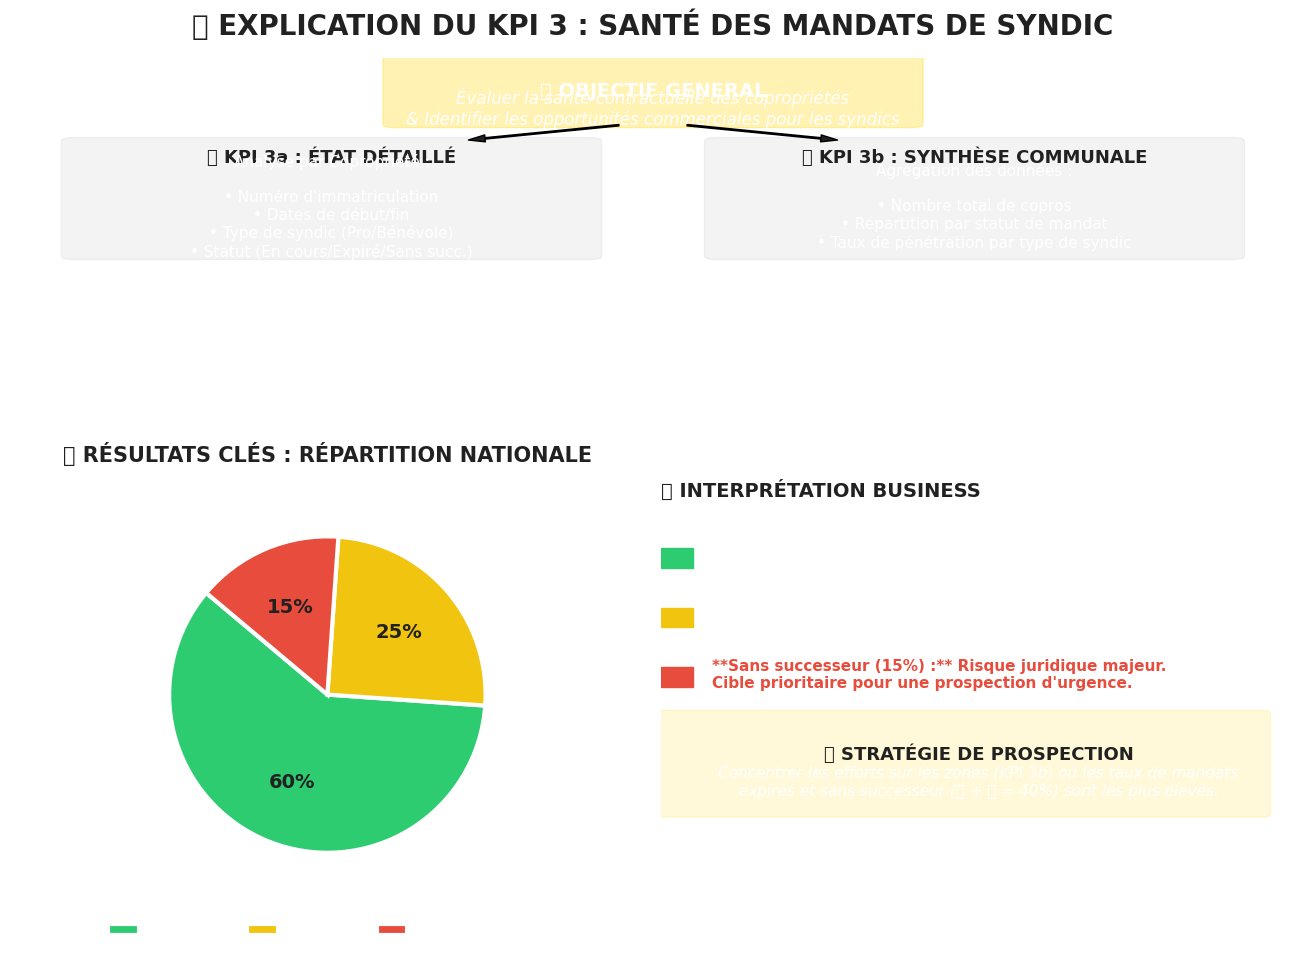

In [438]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch # Importation nécessaire

# --- Configuration Globale & Style ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11
# Couleurs : Vert (En cours), Jaune (Expiré), Rouge (Sans successeur)
colors_statut = ['#2ecc71', '#f1c40f', '#e74c3c'] 
# Palette Jaune/Noir/Blanc pour le reste
color_text = '#212121' # Noir mat
color_bg = '#FFFFFF'   # Blanc pur
color_highlight = '#FFD700' # Jaune Or

# Création de la figure principale avec fond blanc
fig = plt.figure(figsize=(14, 10), facecolor=color_bg)
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1.2]) # Structure 2x2

# ------------------------------------------------------------------
# PARTIE SUPÉRIEURE : Diagramme de Structure (Explication de la logique)
# ------------------------------------------------------------------
ax_struct = fig.add_subplot(gs[0, :]) # Occupe toute la largeur du haut
ax_struct.axis('off') # Cache les axes

# Titre Principal de l'infographie
ax_struct.text(0.5, 1.1, "📋 EXPLICATION DU KPI 3 : SANTÉ DES MANDATS DE SYNDIC", 
               ha='center', va='center', size=20, weight='bold', color=color_text)

# Zone Objectif - Remplacement par FancyBboxPatch pour les coins arrondis
fancy_box_obj = FancyBboxPatch((0.3, 0.8), 0.4, 0.2, color=color_highlight, alpha=0.3, 
                                 boxstyle="round,pad=0.01", transform=ax_struct.transAxes)
ax_struct.add_patch(fancy_box_obj)
ax_struct.text(0.5, 0.9, "🎯 OBJECTIF GENERAL", ha='center', va='center', size=14, weight='bold', transform=ax_struct.transAxes)
ax_struct.text(0.5, 0.85, "Évaluer la santé contractuelle des copropriétés\n& Identifier les opportunités commerciales pour les syndics", 
               ha='center', va='center', size=12, transform=ax_struct.transAxes, style='italic')

# Flèches vers le bas
ax_struct.annotate('', xy=(0.35, 0.75), xytext=(0.48, 0.8), arrowprops=dict(facecolor=color_text, shrink=0.05, width=1, headwidth=5))
ax_struct.annotate('', xy=(0.65, 0.75), xytext=(0.52, 0.8), arrowprops=dict(facecolor=color_text, shrink=0.05, width=1, headwidth=5))

# Zone KPI 3a : Détaillé (Gauche) - Remplacement par FancyBboxPatch
fancy_box_3a = FancyBboxPatch((0.05, 0.4), 0.4, 0.35, color=color_text, alpha=0.05, 
                                 boxstyle="round,pad=0.01", transform=ax_struct.transAxes)
ax_struct.add_patch(fancy_box_3a)
ax_struct.text(0.25, 0.7, "📊 KPI 3a : ÉTAT DÉTAILLÉ", ha='center', va='center', size=13, weight='bold', transform=ax_struct.transAxes, color=color_text)
ax_struct.text(0.25, 0.55, "Analyse par Copropriété :\n\n• Numéro d'immatriculation\n• Dates de début/fin\n• Type de syndic (Pro/Bénévole)\n• Statut (En cours/Expiré/Sans succ.)", 
               ha='center', va='center', size=11, transform=ax_struct.transAxes)

# Zone KPI 3b : Synthèse (Droite) - Remplacement par FancyBboxPatch
fancy_box_3b = FancyBboxPatch((0.55, 0.4), 0.4, 0.35, color=color_text, alpha=0.05, 
                                 boxstyle="round,pad=0.01", transform=ax_struct.transAxes)
ax_struct.add_patch(fancy_box_3b)
ax_struct.text(0.75, 0.7, "📊 KPI 3b : SYNTHÈSE COMMUNALE", ha='center', va='center', size=13, weight='bold', transform=ax_struct.transAxes, color=color_text)
ax_struct.text(0.75, 0.55, "Agrégation des données :\n\n• Nombre total de copros\n• Répartition par statut de mandat\n• Taux de pénétration par type de syndic", 
               ha='center', va='center', size=11, transform=ax_struct.transAxes)


# ------------------------------------------------------------------
# PARTIE INFÉRIEURE GAUCHE : Résultats Clés (Camembert)
# ------------------------------------------------------------------
ax_pie = fig.add_subplot(gs[1, 0])
ax_pie.set_facecolor(color_bg)

# Données des résultats clés
labels_pie = ['En cours', 'Expirés', 'Sans successeur']
sizes_pie = [60, 25, 15]

# Création du camembert "Flat Design"
wedges, texts, autotexts = ax_pie.pie(
    sizes_pie, 
    labels=None, # Pas de labels autour, on utilise la légende
    autopct='%1.0f%%', 
    startangle=140, 
    colors=colors_statut, 
    shadow=False, 
    wedgeprops={"edgecolor":color_bg, 'linewidth': 3}, # Bordures blanches épaisses
    textprops=dict(color=color_text, size=14, weight="bold")
)

# Légende personnalisée en dessous
ax_pie.legend(wedges, labels_pie, title="Statut des Mandats", loc="lower center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)

# Titre de la partie résultats
ax_pie.set_title("🔍 RÉSULTATS CLÉS : RÉPARTITION NATIONALE", size=15, weight='bold', pad=25, color=color_text)


# ------------------------------------------------------------------
# PARTIE INFÉRIEURE DROITE : Légende & Interprétation Business
# ------------------------------------------------------------------
ax_text = fig.add_subplot(gs[1, 1])
ax_text.axis('off') # Cache les axes

# Texte explicatif des statuts (Interprétation business)
y_start = 0.85
ax_text.text(0.0, 1.0, "💡 INTERPRÉTATION BUSINESS", size=14, weight='bold', transform=ax_text.transAxes, color=color_text)

# Carrés de couleur + texte
# 🟢 Vert
# plt.Rectangle fonctionne ici car pas de boxstyle
ax_text.add_patch(plt.Rectangle((0.0, y_start-0.03), 0.05, 0.05, color=colors_statut[0], transform=ax_text.transAxes)) 
ax_text.text(0.08, y_start, "**Mandats en cours (60%) :** Copropriétés contractuellement saines.\nCible de fidélisation.", 
             va='center', transform=ax_text.transAxes, size=11)

# 🟡 Jaune
# plt.Rectangle fonctionne ici car pas de boxstyle
ax_text.add_patch(plt.Rectangle((0.0, y_start-0.18), 0.05, 0.05, color=colors_statut[1], transform=ax_text.transAxes))
ax_text.text(0.08, y_start-0.15, "**Mandats expirés (25%) :** Situation administrative à régulariser.\nOpportunité commerciale immédiate de renouvellement.", 
             va='center', transform=ax_text.transAxes, size=11)

# 🔴 Rouge
# plt.Rectangle fonctionne ici car pas de boxstyle
ax_text.add_patch(plt.Rectangle((0.0, y_start-0.33), 0.05, 0.05, color=colors_statut[2], transform=ax_text.transAxes))
ax_text.text(0.08, y_start-0.30, "**Sans successeur (15%) :** Risque juridique majeur.\nCible prioritaire pour une prospection d'urgence.", 
             va='center', transform=ax_text.transAxes, size=11, color='#e74c3c', weight='bold')

# Petit encadré "Conseil" - Remplacement par FancyBboxPatch
fancy_box_conseil = FancyBboxPatch((0.0, 0.2), 0.95, 0.25, color=color_highlight, alpha=0.15, 
                                     boxstyle="round,pad=0.01", transform=ax_text.transAxes)
ax_text.add_patch(fancy_box_conseil)
ax_text.text(0.5, 0.35, "🚀 STRATÉGIE DE PROSPECTION", ha='center', va='center', size=13, weight='bold', transform=ax_text.transAxes, color=color_text)
ax_text.text(0.5, 0.28, "Concentrer les efforts sur les zones (KPI 3b) où les taux de mandats\nexpirés et sans successeur (🔴 + 🟡 = 40%) sont les plus élevés.", 
             ha='center', va='center', size=11, transform=ax_text.transAxes, style='italic')


# Affichage final
plt.tight_layout()
plt.subplots_adjust(top=0.9, hspace=0.3) # Ajuste les espacements
plt.show()

In [418]:
kpi3_mandats = sql(f"""
SELECT
    id_copro,
    COALESCE(nom_copro, '(sans nom)')       AS nom_copro,
    COALESCE(ville, code_commune, '?')       AS ville,
    code_commune,
    COALESCE(type_syndic, '?')              AS type_syndic,
    CAST(COALESCE(nb_lots_hab, 0)  AS INTEGER)  AS nb_lots_habitation,
    CAST(COALESCE(nb_lots_stat, 0) AS INTEGER)  AS nb_lots_stationnement,
    ROUND(
        CAST(COALESCE(nb_lots_stat, 0) AS REAL)
        / NULLIF(CAST(COALESCE(nb_lots_hab, 0) AS REAL), 0) * 100
    , 1) AS pct_places_par_logement,

    statut_mandat,
    date_immat_str                          AS date_immatriculation,
    date_fin_mandat_str                     AS date_fin_mandat,

    -- Ancienneté depuis immatriculation
    ROUND(
        (julianday('{TODAY}') - julianday(date_immat_str)) / 30.44
    , 0) AS anciennete_mois,

    CASE
        WHEN (julianday('{TODAY}') - julianday(date_immat_str)) / 30.44 < 6   THEN '🆕 Nouveau (< 6 mois)'
        WHEN (julianday('{TODAY}') - julianday(date_immat_str)) / 30.44 < 24  THEN '🟢 Récent (6–24 mois)'
        WHEN (julianday('{TODAY}') - julianday(date_immat_str)) / 30.44 < 60  THEN '🔵 Établi (2–5 ans)'
        ELSE                                                                        '⚫ Historique (> 5 ans)'
    END AS anciennete_label,

    -- Jours avant fin de mandat
    CAST(julianday(date_fin_mandat_str) - julianday('{TODAY}') AS INTEGER) AS jours_avant_fin,

    -- Alerte commerciale
    CASE
        WHEN statut_mandat LIKE '%expiré%'  THEN '❌ Expiré — ne pas contacter'
        WHEN date_fin_mandat_str IS NULL    THEN '⚪ Pas de date — vérifier'
        WHEN julianday(date_fin_mandat_str) - julianday('{TODAY}') < 0
            THEN '❌ Mandat terminé — ne pas contacter'
        WHEN julianday(date_fin_mandat_str) - julianday('{TODAY}') <= {SEUIL_FIN_PROCHE_JOURS}
            THEN '⚠️  Fin imminente — éviter ({SEUIL_FIN_PROCHE_JOURS} jours)'
        ELSE '✅ Actif — à prospecter'
    END AS alerte_commerciale

FROM coproprietes
WHERE nb_lots_hab > 0
  AND date_immat_str IS NOT NULL
  -- Exclure les mandats expirés sans successeur (interlocuteur instable)
  AND statut_mandat != 'Mandat expiré sans successeur déclaré'
ORDER BY
    -- En tête : les copros avec le plus de stationnement ET mandat actif
    CASE WHEN alerte_commerciale LIKE '✅%' THEN 0 ELSE 1 END ASC,
    nb_lots_stationnement DESC,
    nb_lots_habitation DESC
""")

print(f"✅ KPI 3 — {len(kpi3_mandats):,} copropriétés analysées")
print(f"  ↳ À prospecter (actives) : {(kpi3_mandats['alerte_commerciale'].str.startswith('✅')).sum():,}")
print(f"  ↳ À éviter (fin imminente) : {(kpi3_mandats['alerte_commerciale'].str.startswith('⚠️')).sum():,}")
print(f"  ↳ Expirées / à ne pas contacter : {(kpi3_mandats['alerte_commerciale'].str.startswith('❌')).sum():,}")
kpi3_mandats.head(30)

✅ KPI 3 — 4,717 copropriétés analysées
  ↳ À prospecter (actives) : 2,647
  ↳ À éviter (fin imminente) : 492
  ↳ Expirées / à ne pas contacter : 1,578


,id_copro,nom_copro,ville,code_commune,type_syndic,nb_lots_habitation,nb_lots_stationnement,pct_places_par_logement,statut_mandat,date_immatriculation,date_fin_mandat,anciennete_mois,anciennete_label,jours_avant_fin,alerte_commerciale
0,AA0796326,LE LOGIS VERT,Le Petit-Quevilly,76498,professionnel,444,485,109.2,Mandat en cours,2016-12-29,2026-12-31,111.0,⚫ Historique (> 5 ans),275,✅ Actif — à prospecter
1,AA0290411,RESIDENCE PARC DE PETIT BOURG,Évry,91228,professionnel,502,484,96.4,Mandat en cours,2016-11-30,2026-06-30,112.0,⚫ Historique (> 5 ans),91,✅ Actif — à prospecter
2,AA1169051,PALMER,Cenon,33119,professionnel,371,366,98.7,Mandat en cours,2017-01-25,2026-09-11,110.0,⚫ Historique (> 5 ans),164,✅ Actif — à prospecter
3,AB6421325,HORIZON SCHUMAN,Marseille,13202,professionnel,133,360,270.7,Mandat en cours,2017-12-07,2027-05-21,100.0,⚫ Historique (> 5 ans),416,✅ Actif — à prospecter
4,AA0718114,LES CHAMPS PERDRIX,Dijon,21231,professionnel,313,347,110.9,Mandat en cours,2017-02-27,2027-05-25,109.0,⚫ Historique (> 5 ans),420,✅ Actif — à prospecter
5,AA0748566,RESIDENCE LES COTEAUX,ST HERBLAIN,44162,professionnel,310,325,104.8,Mandat en cours,2016-12-29,2026-12-18,111.0,⚫ Historique (> 5 ans),262,✅ Actif — à prospecter
6,AA1603745,NOUVEAU PALACE,Montpellier,34172,professionnel,255,321,125.9,Mandat en cours,2017-02-06,2027-05-15,110.0,⚫ Historique (> 5 ans),410,✅ Actif — à prospecter
7,AB8689762,SDC LE LAUREAT I,Besançon,25056,professionnel,342,315,92.1,Mandat en cours,2018-01-16,2027-02-28,98.0,⚫ Historique (> 5 ans),334,✅ Actif — à prospecter
8,AC5299334,SDC Entre Ville 2,Sarcelles,95585,professionnel,259,311,120.1,Mandat en cours,2018-05-14,2028-09-04,95.0,⚫ Historique (> 5 ans),888,✅ Actif — à prospecter
9,AG0054882,OXYGEN,Marseille,13210,professionnel,178,298,167.4,Mandat en cours,2020-03-03,2026-12-31,73.0,⚫ Historique (> 5 ans),275,✅ Actif — à prospecter


In [419]:
# Vue synthétique — répartition par ancienneté et statut commercial
kpi3_synthese = sql(f"""
SELECT
    CASE
        WHEN statut_mandat LIKE '%expiré%'  THEN '❌ Expiré'
        WHEN date_fin_mandat_str IS NULL    THEN '⚪ Sans date'
        WHEN julianday(date_fin_mandat_str) - julianday('{TODAY}') < 0
            THEN '❌ Mandat terminé'
        WHEN julianday(date_fin_mandat_str) - julianday('{TODAY}') <= {SEUIL_FIN_PROCHE_JOURS}
            THEN '⚠️  Fin imminente'
        ELSE '✅ Actif'
    END AS statut_commercial,
    CASE
        WHEN (julianday('{TODAY}') - julianday(date_immat_str)) / 30.44 < 6   THEN 'Nouveau'
        WHEN (julianday('{TODAY}') - julianday(date_immat_str)) / 30.44 < 24  THEN 'Récent'
        WHEN (julianday('{TODAY}') - julianday(date_immat_str)) / 30.44 < 60  THEN 'Établi'
        ELSE 'Historique'
    END AS anciennete,
    COUNT(*) AS nb_copros,
    SUM(CAST(COALESCE(nb_lots_stat, 0) AS INTEGER)) AS total_lots_stat,
    ROUND(AVG(CAST(COALESCE(nb_lots_stat, 0) AS REAL)), 1) AS moy_lots_stat
FROM coproprietes
WHERE nb_lots_hab > 0
  AND date_immat_str IS NOT NULL
  AND statut_mandat != 'Mandat expiré sans successeur déclaré'
GROUP BY statut_commercial, anciennete
ORDER BY statut_commercial, total_lots_stat DESC
""")

print("✅ KPI 3b — Synthèse mandats")
kpi3_synthese

✅ KPI 3b — Synthèse mandats


,statut_commercial,anciennete,nb_copros,total_lots_stat,moy_lots_stat
0,⚠️ Fin imminente,Historique,406,7124,17.5
1,⚠️ Fin imminente,Établi,73,1233,16.9
2,⚠️ Fin imminente,Récent,13,174,13.4
3,✅ Actif,Historique,2220,41839,18.8
4,✅ Actif,Établi,307,7442,24.2
5,✅ Actif,Récent,103,2483,24.1
6,✅ Actif,Nouveau,17,155,9.1
7,❌ Expiré,Historique,5,36,7.2
8,❌ Expiré,Établi,1,35,35.0
9,❌ Mandat terminé,Historique,1293,20658,16.0


### 📈 Graphique KPI 3 — Mandats

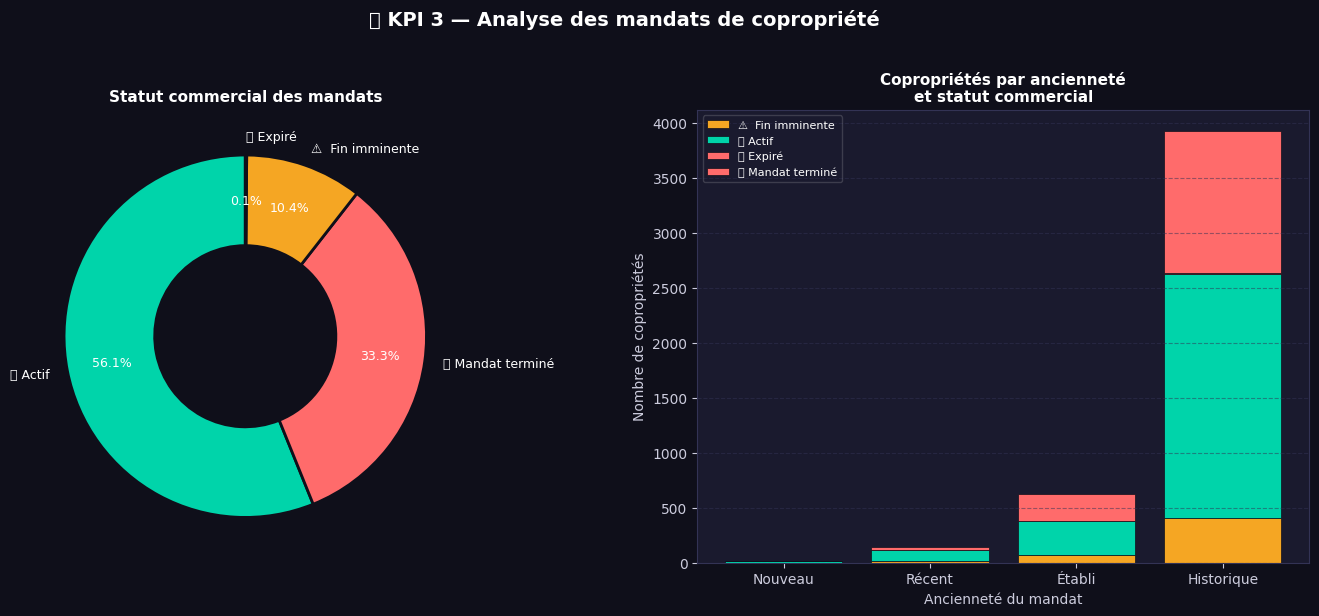

In [420]:
# ── KPI 3 — Répartition mandats : donut + barres ancienneté ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Donut statuts commerciaux ---
ax = axes[0]
statuts = kpi3_mandats['alerte_commerciale'].value_counts()
clean_labels = [l.split('—')[0].strip() if '—' in l else l.strip() for l in statuts.index]
colors_donut = []
for l in statuts.index:
    if '✅' in l:   colors_donut.append(TEAL)
    elif '⚠️' in l: colors_donut.append(AMBER)
    elif '❌' in l: colors_donut.append(CORAL)
    else:            colors_donut.append(GREY)

wedges, texts, autotexts = ax.pie(
    statuts.values, labels=clean_labels, colors=colors_donut,
    autopct='%1.1f%%', startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.5, edgecolor='#0f0f1a', linewidth=2)
)
for t in autotexts: t.set_color('white'); t.set_fontsize(9)
for t in texts: t.set_color('white'); t.set_fontsize(9)
ax.set_title('Statut commercial des mandats', fontsize=11, fontweight='bold')

# --- Barres ancienneté x statut ---
ax2 = axes[1]
pivot = kpi3_synthese.pivot_table(
    index='anciennete', columns='statut_commercial',
    values='nb_copros', aggfunc='sum', fill_value=0
)
order = ['Nouveau', 'Récent', 'Établi', 'Historique']
pivot = pivot.reindex([o for o in order if o in pivot.index])
col_colors = {c: TEAL if '✅' in c else AMBER if '⚠️' in c else CORAL if '❌' in c else GREY
              for c in pivot.columns}
bottom = np.zeros(len(pivot))
for col in pivot.columns:
    ax2.bar(pivot.index, pivot[col], bottom=bottom,
            label=col.split('—')[0].strip(), color=col_colors.get(col, GREY),
            edgecolor='#0f0f1a', linewidth=0.5)
    bottom += pivot[col].values
ax2.set_xlabel('Ancienneté du mandat')
ax2.set_ylabel('Nombre de copropriétés')
ax2.set_title('Copropriétés par ancienneté\net statut commercial', fontsize=11, fontweight='bold')
ax2.legend(fontsize=8, framealpha=0.2)
ax2.grid(axis='y')

fig.suptitle('📋 KPI 3 — Analyse des mandats de copropriété', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('graph_kpi3_mandats.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📊 KPI 4 — Ratio Places de Stationnement / Logements

> **Lecture :** Le ratio mesure la pression sur le stationnement.
> - **Ratio > 1** : plus de places que de logements → surplus, fort potentiel de partage
> - **Ratio 0.5–1** : équilibre, certains ménages n'ont pas de place → tension partielle
> - **Ratio < 0.5** : forte tension → les gens cherchent des places, demande élevée
>
> Notre app cible les **deux côtés** : les communes en surplus (propriétaires qui peuvent louer leur place) ET en tension (locataires qui cherchent).

In [ ]:
kpi4_ratio = sql("""
SELECT
    code_commune,
    COALESCE(nom_commune, code_commune) AS ville,
    code_commune AS departement,
    code_commune AS region,
    CAST(nb_logements         AS INTEGER) AS nb_logements,
    CAST(nb_appartements      AS INTEGER) AS nb_appartements,
    CAST(nb_lots_stat_total   AS INTEGER) AS lots_stat_copro,
    CAST(nb_places_publiques  AS INTEGER) AS places_publiques,
    CAST(nb_copros_sans_stat  AS INTEGER) AS copros_sans_stat,
    CAST(nb_menages_avec_voiture AS INTEGER) AS menages_motorises,
    CAST(nb_menages_avec_parking AS INTEGER) AS menages_avec_parking,

    -- Ratio places copro / logements
    ROUND(
        CAST(nb_lots_stat_total AS REAL) / NULLIF(CAST(nb_logements AS REAL), 0)
    , 3) AS ratio_stat_par_logement,

    -- % ménages motorisés sans parking → demande potentielle
    ROUND(
        CASE 
            WHEN CAST(nb_menages_avec_voiture AS REAL) - CAST(nb_menages_avec_parking AS REAL) > 0
            THEN (CAST(nb_menages_avec_voiture AS REAL) - CAST(nb_menages_avec_parking AS REAL))
            ELSE 0
        END / NULLIF(CAST(nb_menages AS REAL), 0) * 100
    , 1) AS pct_motorises_sans_parking,

    -- Profil de la commune avec des seuils plus réalistes
    CASE
        WHEN CAST(nb_lots_stat_total AS REAL) / NULLIF(CAST(nb_logements AS REAL), 0) >= 0.8
            THEN '🟢 Surplus — offre disponible à louer'
        WHEN CAST(nb_lots_stat_total AS REAL) / NULLIF(CAST(nb_logements AS REAL), 0) >= 0.4
            THEN '🟡 Équilibre — marché des deux côtés'
        WHEN CAST(nb_lots_stat_total AS REAL) / NULLIF(CAST(nb_logements AS REAL), 0) >= 0.15
            THEN '🟠 Tension — forte demande de places'
        ELSE
            '🔴 Forte tension — priorité demande'
    END AS profil_stationnement,

    -- Score d'intérêt pour l'app (offre × demande)
    ROUND(
        CAST(nb_lots_stat_total AS REAL)
        * CASE 
            WHEN CAST(nb_menages_avec_voiture AS REAL) - CAST(nb_menages_avec_parking AS REAL) > 0
            THEN (CAST(nb_menages_avec_voiture AS REAL) - CAST(nb_menages_avec_parking AS REAL) + 1)
            ELSE 1
        END / NULLIF(CAST(nb_logements AS REAL), 0)
    , 1) AS index_partageabilite

FROM communes
WHERE nb_logements > 50
  AND nb_copros > 0
ORDER BY index_partageabilite DESC
""")

print(f"✅ KPI 4 — {len(kpi4_ratio):,} communes avec analyse du ratio stationnement")
print(f"\nRépartition des profils :")
print(kpi4_ratio['profil_stationnement'].value_counts().to_string())
print()
kpi4_ratio.head(20)

✅ KPI 4 — 89 communes avec analyse du ratio stationnement

Répartition des profils :
profil_stationnement
🔴 Forte tension — priorité demande    89



,code_commune,ville,departement,region,nb_logements,nb_appartements,lots_stat_copro,places_publiques,copros_sans_stat,menages_motorises,menages_avec_parking,ratio_stat_par_logement,pct_motorises_sans_parking,profil_stationnement,index_partageabilite
0,68224,Mulhouse,68224,68224,58439,50028,1319,0,60,32489,18575,0.023,29.0,🔴 Forte tension — priorité demande,314.1
1,69029,Bron,69029,69029,19831,16491,1167,0,2,14114,11202,0.059,15.9,🔴 Forte tension — priorité demande,171.4
2,69256,Vaulx-en-Velin,69256,69256,20353,16418,1010,11,4,13531,10125,0.050,18.2,🔴 Forte tension — priorité demande,169.1
3,57463,Metz,57463,57463,70903,60466,899,9726,5,43467,32948,0.013,17.2,🔴 Forte tension — priorité demande,133.4
4,67482,Strasbourg,67482,67482,162246,149471,567,11554,28,86270,56248,0.003,21.4,🔴 Forte tension — priorité demande,104.9
5,66136,Perpignan,66136,66136,73808,54107,578,0,58,43671,31240,0.008,20.9,🔴 Forte tension — priorité demande,97.4
6,69389,Lyon 9e Arrondissement,69389,69389,30365,28567,636,0,2,16233,12018,0.021,16.4,🔴 Forte tension — priorité demande,88.3
7,59017,59017,59017,59017,12686,5645,280,450,2,8610,4732,0.022,33.9,🔴 Forte tension — priorité demande,85.6
8,69286,Rillieux-la-Pape,69286,69286,13137,9846,222,0,6,9514,5168,0.017,35.7,🔴 Forte tension — priorité demande,73.5
9,69199,Saint-Fons,69199,69199,8147,6797,246,0,0,5512,3327,0.030,28.8,🔴 Forte tension — priorité demande,66.0


# ── Vérification des variables KPI disponibles ───────────────────────────────
print("Variables KPI disponibles :")
kpi_vars = ['kpi1', 'kpi2_villes', 'kpi2_depts', 'kpi3_mandats', 'kpi3_synthese', 'kpi4_ratio', 'kpi4_copros']
for var in kpi_vars:
    if var in locals():
        print(f"  ✅ {var}: {len(locals()[var])} lignes")
    else:
        print(f"  ❌ {var}: non défini")

In [422]:
# ── 5. Export CSV des KPIs ───────────────────────────────────────────────────
# Tous les résultats sont exportés en fichiers CSV séparés pour faciliter la réutilisation

# Export KPI 1 - Score potentiel par ville
kpi1.to_csv('kpi1_score_potentiel_villes.csv', index=False, encoding='utf-8-sig')
print("✅ KPI 1 exporté → kpi1_score_potentiel_villes.csv")
print(f"   📊 {len(kpi1)} villes exportées")

In [425]:
kpi1.to_csv('kpi1_score_potentiel_villes.csv', index=False, encoding='utf-8-sig')
print("✅ KPI 1 exporté → kpi1_score_potentiel_villes.csv")
print(f"   📊 {len(kpi1)} villes exportées")

✅ KPI 1 exporté → kpi1_score_potentiel_villes.csv
   📊 70 villes exportées


In [423]:
# Export KPI 2a - Zones prioritaires (villes)
kpi2_villes.to_csv('kpi2_zones_prioritaires_villes.csv', index=False, encoding='utf-8-sig')
print("✅ KPI 2a exporté → kpi2_zones_prioritaires_villes.csv")
print(f"   📍 {len(kpi2_villes)} villes prioritaires exportées")

✅ KPI 2a exporté → kpi2_zones_prioritaires_villes.csv
   📍 20 villes prioritaires exportées


# Export KPI 2b - Zones prioritaires (départements)
kpi2_depts.to_csv('kpi2_zones_prioritaires_departements.csv', index=False, encoding='utf-8-sig')
print("✅ KPI 2b exporté → kpi2_zones_prioritaires_departements.csv")
print(f"   🏛️ {len(kpi2_depts)} départements prioritaires exportés")

In [427]:
# Export KPI 3a - Mandats de copropriété
kpi3_mandats.to_csv('kpi3_mandats_coproprietes.csv', index=False, encoding='utf-8-sig')
print("✅ KPI 3a exporté → kpi3_mandats_coproprietes.csv")
print(f"   📋 {len(kpi3_mandats)} mandats exportés")

✅ KPI 3a exporté → kpi3_mandats_coproprietes.csv
   📋 4717 mandats exportés


In [428]:
# Export KPI 3b - Synthèse des mandats
kpi3_synthese.to_csv('kpi3_synthese_mandats.csv', index=False, encoding='utf-8-sig')
print("✅ KPI 3b exporté → kpi3_synthese_mandats.csv")
print(f"   📊 {len(kpi3_synthese)} lignes de synthèse exportées")

# Export du dataset consolidé complet
df_communes.to_csv('dataset_consolidé_communes.csv', index=False, encoding='utf-8-sig')
print("✅ Dataset consolidé exporté → dataset_consolidé_communes.csv")
print(f"   🏘️ {len(df_communes)} communes exportées")
print(f"   📊 Colonnes : {len(df_communes.columns)}")
print(f"   📋 Taille du fichier : {df_communes.memory_usage(deep=True).sum() / 1024:.1f} KB")

✅ KPI 3b exporté → kpi3_synthese_mandats.csv
   📊 13 lignes de synthèse exportées
✅ Dataset consolidé exporté → dataset_consolidé_communes.csv
   🏘️ 456 communes exportées
   📊 Colonnes : 24
   📋 Taille du fichier : 123.7 KB
